<a id="time_analysis"></a>
## Extended Time Analysis

This section provides comprehensive time-based analysis of article distribution patterns and trends.

### Contents:
* [Overall Time Distribution](#overall_time_enhanced)
* [Time Distribution by Publisher](#time_by_publisher)  
* [Time Distribution by Section](#time_by_section)
* [Average Article Length Over Time](#length_over_time)

### Setup and Imports

Load necessary libraries and custom utility functions from `utils.py`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime

# Import custom utilities
import importlib
import utils
importlib.reload(utils)
from utils import (
    compare_histograms, 
    line_time_plot, 
    stacked_time_plot,
    plot_overall_time_distribution,
    plot_publisher_time_distribution,
    interactive_pie_charts,
    proportional_stacked_plot,
    analyze_article_length_over_time
)

### Data Loading

Load the cleaned article dataset and perform initial exploration.

In [3]:
df = pd.read_pickle("../data/cleaned/cleaned_articles (2).pkl")
df.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua, Washington ...","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,"[Brazil, Lima (Capital)]","[New York, US, United States]",NYT/1.DOCX,The New York Times,world; americas,World/International
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters


In [4]:
print("Available columns:", df.columns.tolist())

Available columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw', 'section_clean', 'section_category']


### Data Preparation

Create derived features needed for analysis:
- `word_count`: Count words in article body
- `year`, `year_month`: Extract temporal features from dates

In [5]:
# Create word count from body text
def count_words_from_body(text):
    """Count words in the body text"""
    if pd.isna(text):
        return 0
    return len(str(text).split())

df['word_count'] = df['body'].apply(count_words_from_body)

# Get publisher counts
publisher_counts = df['publisher'].value_counts()
print("\nPublisher distribution:")
for pub, count in publisher_counts.items():
    print(f"  {pub}: {count:,} articles")


Publisher distribution:
  New York Times: 25,586 articles
  Other publisher: 14,277 articles


In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['year_month'] = df['date'].dt.to_period('M')

<a id="overall_time_enhanced"></a>
### Overall Time Distribution

Generate comprehensive visualizations showing article distribution over time, including both yearly and monthly views with static and interactive plots.

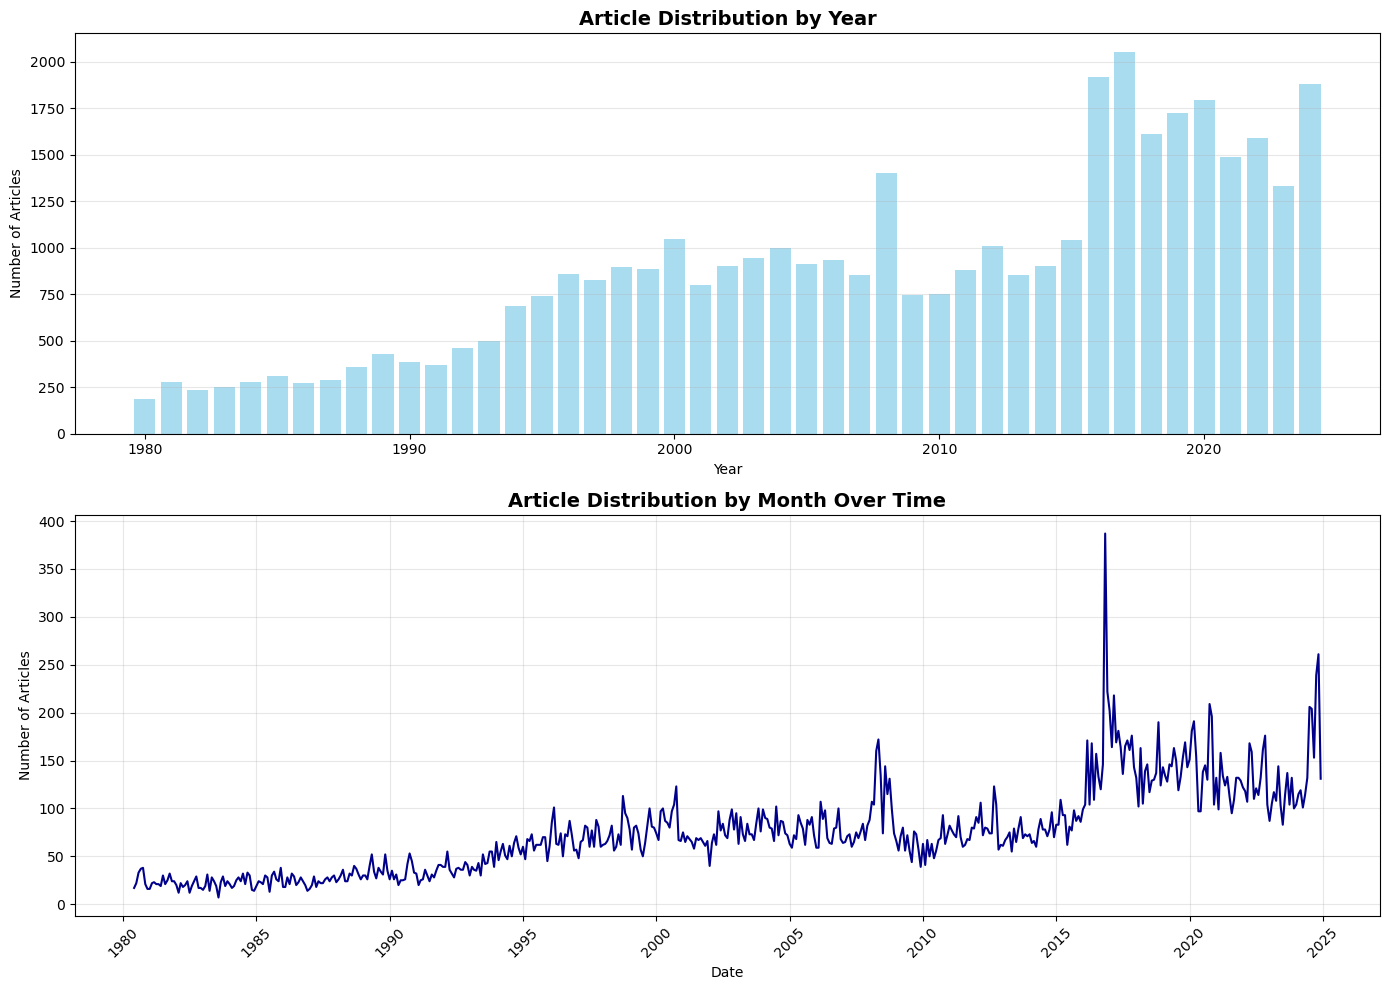

/opt/anaconda3/lib/python3.13/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [7]:
# Create overall time distribution visualizations
plot_overall_time_distribution(df, save_static=True, save_interactive=True)

### Publisher Data Cleaning

Standardize publisher names by removing variations and filter to main publishers.

In [8]:
def clean_publisher(publisher: str) -> str:
    """Standardize publisher names by removing common variations."""
    return (
        publisher.lower()
        .replace("the ", "")
        .replace("blogs", "")
        .replace("(pennsylvania)", " ")
        .replace("(minneapolis, mn)", " ")
        .replace("(ohio)", " ")
        .strip()
    )

In [9]:
df["publisher_clean"] = df["publisher_raw"].apply(clean_publisher)
df = df.loc[df["publisher_clean"] != "february 1, 2007 thursday"]

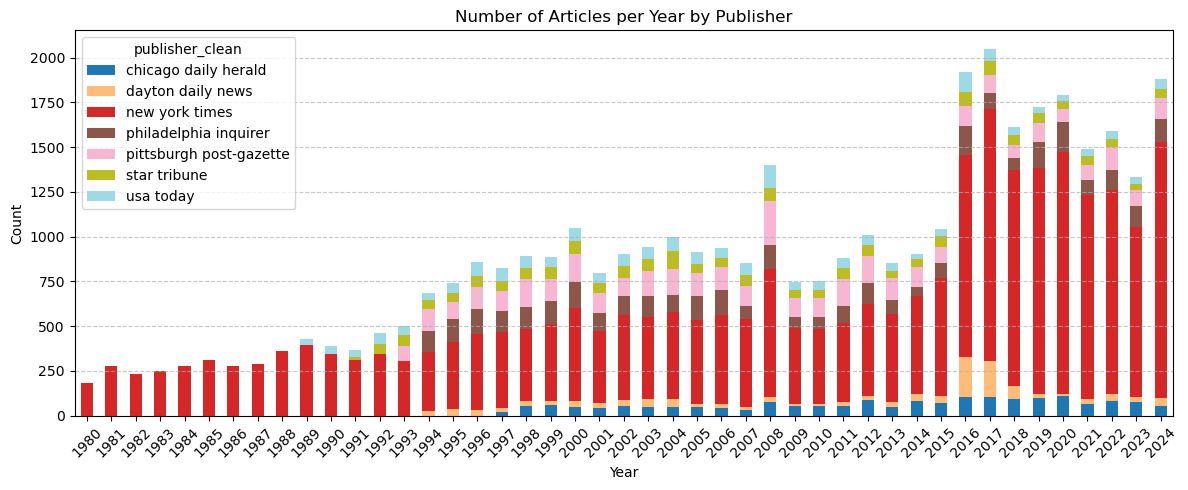

In [10]:
# Parse dates safely
df["parsed_date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["parsed_date"].dt.year

# Group by year + publisher
year_pub_counts = df.groupby(["year", "publisher_clean"]).size().unstack(fill_value=0)

# Plot stacked bar chart
#plt.figure(figsize=(12, 5))
year_pub_counts.plot(
    kind="bar", stacked=True, figsize=(12, 5), colormap="tab20"
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Number of Articles per Year by Publisher")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Elena recommendation: add one more New york times vs other publishers, two colors only, year by year

<a id="time_by_publisher"></a>
### Time Distribution by Publishe

Compare article distribution patterns between NYT and other publishers across multiple visualization types: individual trends, stacked views, line comparisons, and area charts.

Elena recommendation: remove the seperat bar chart for nyt and other publisher
monthly article stacked chart remove


------------------------------------------------------------
ARTICLE DISTRIBUTION BY PUBLISHER OVER TIME
------------------------------------------------------------


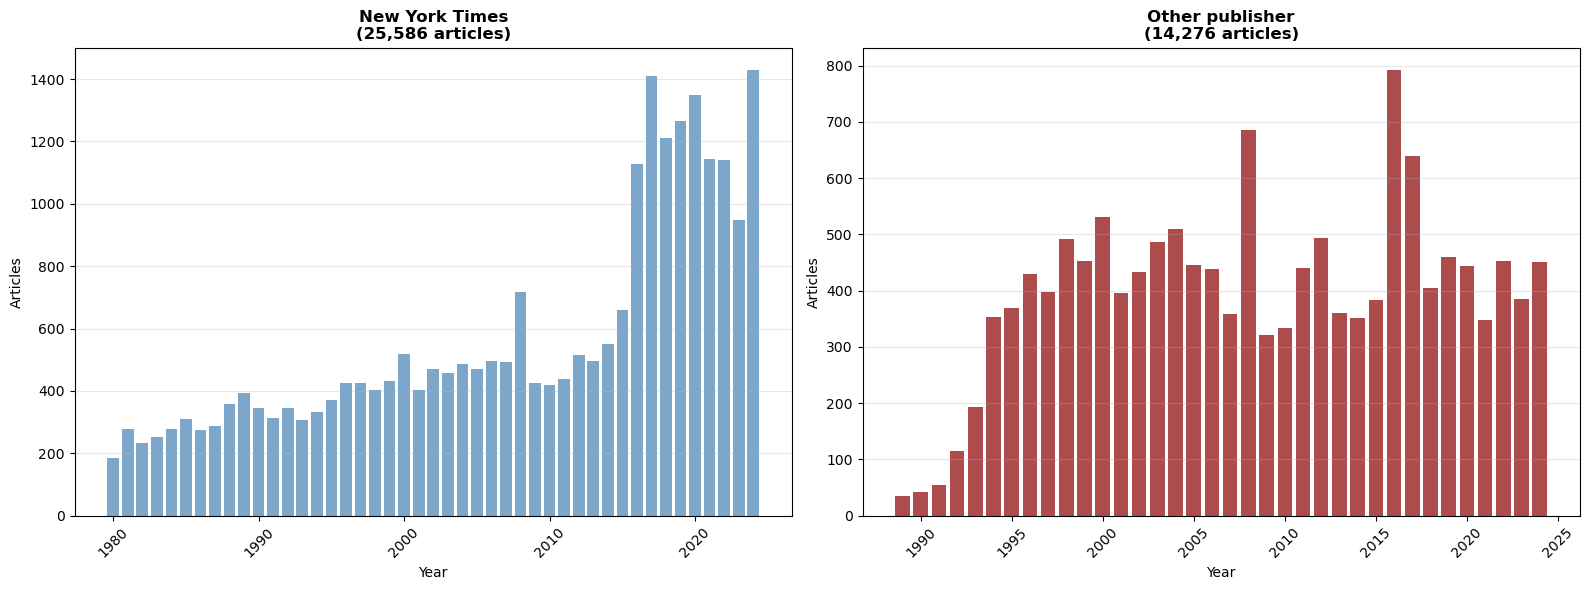

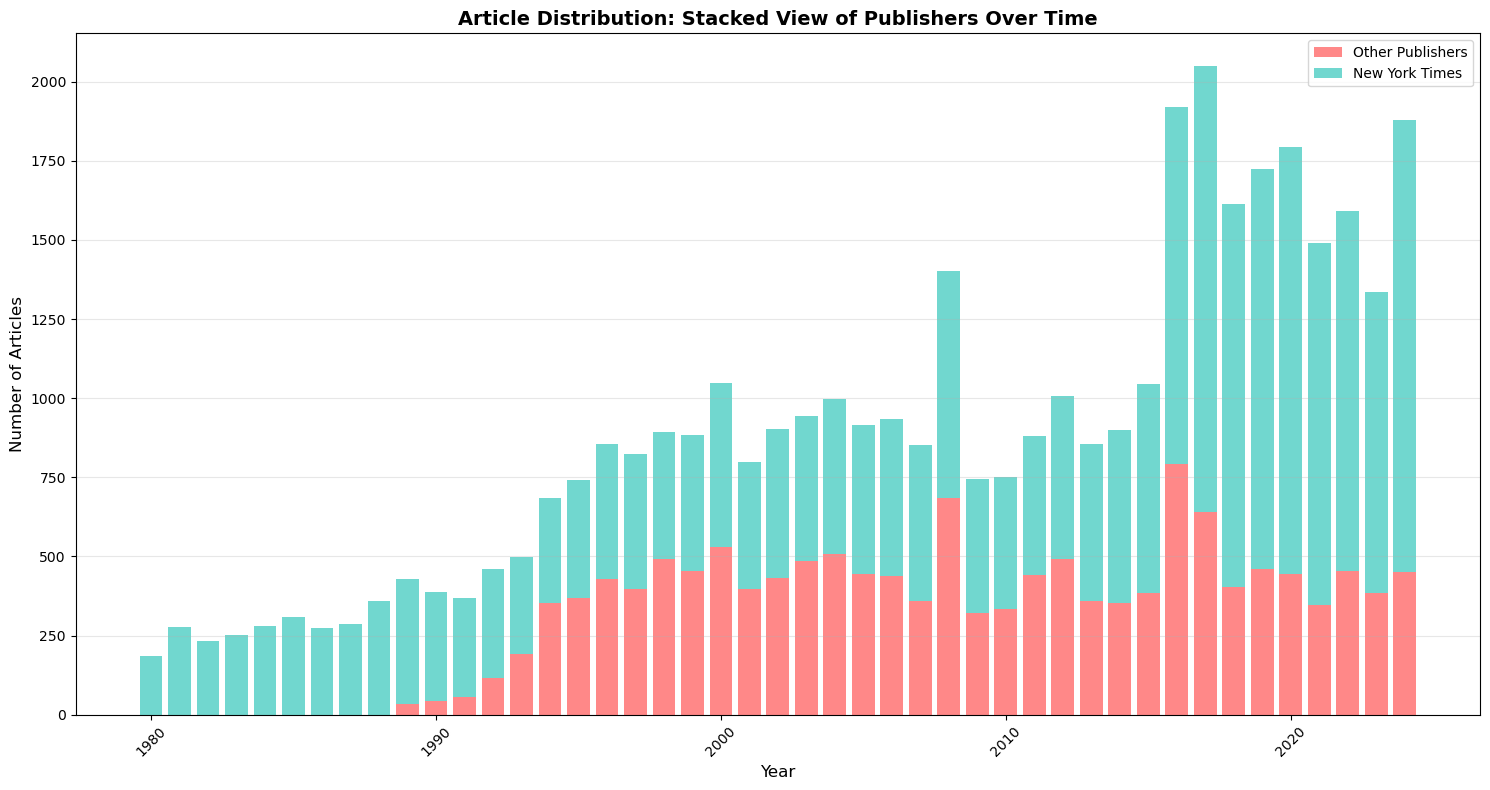

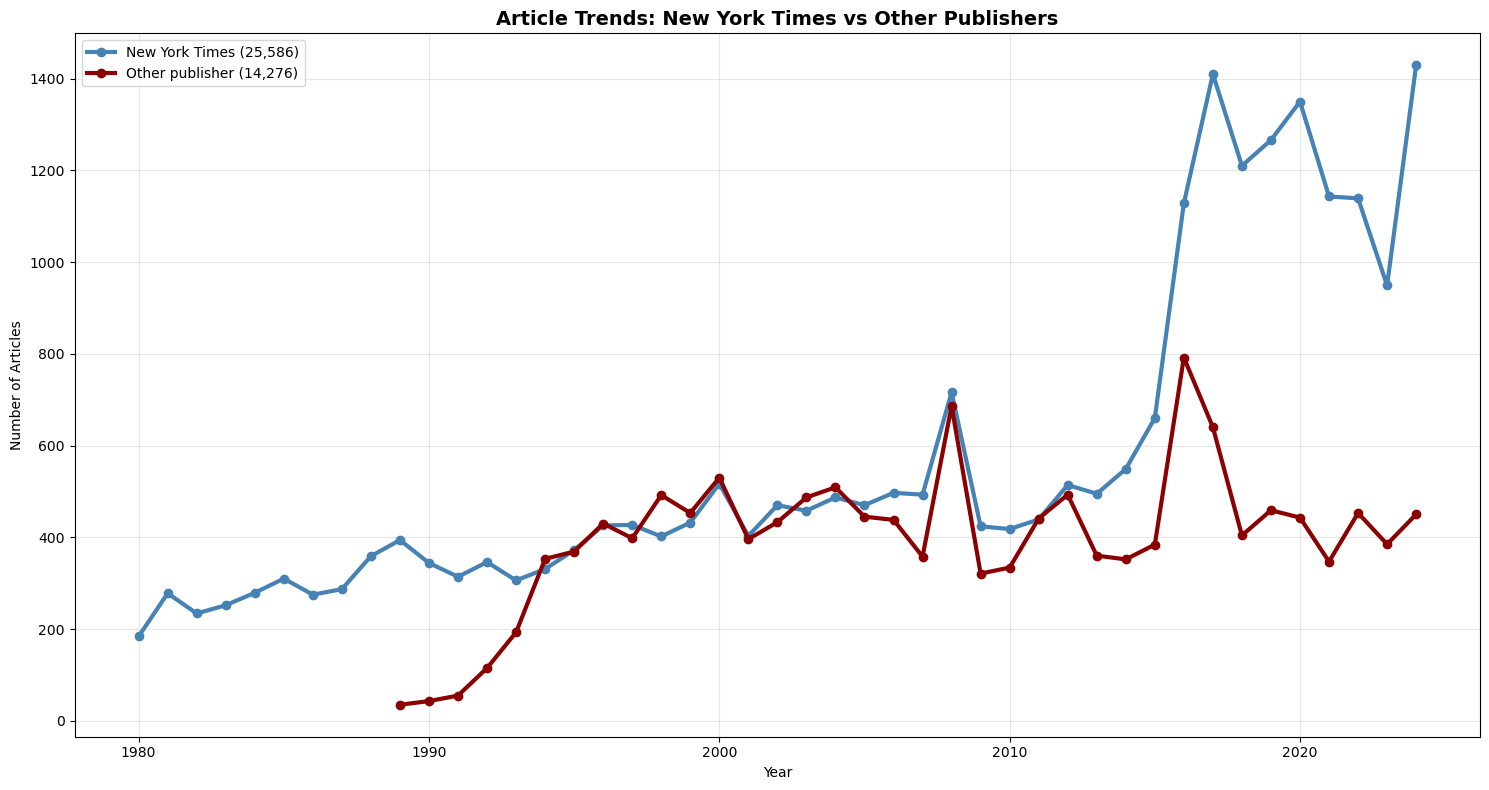

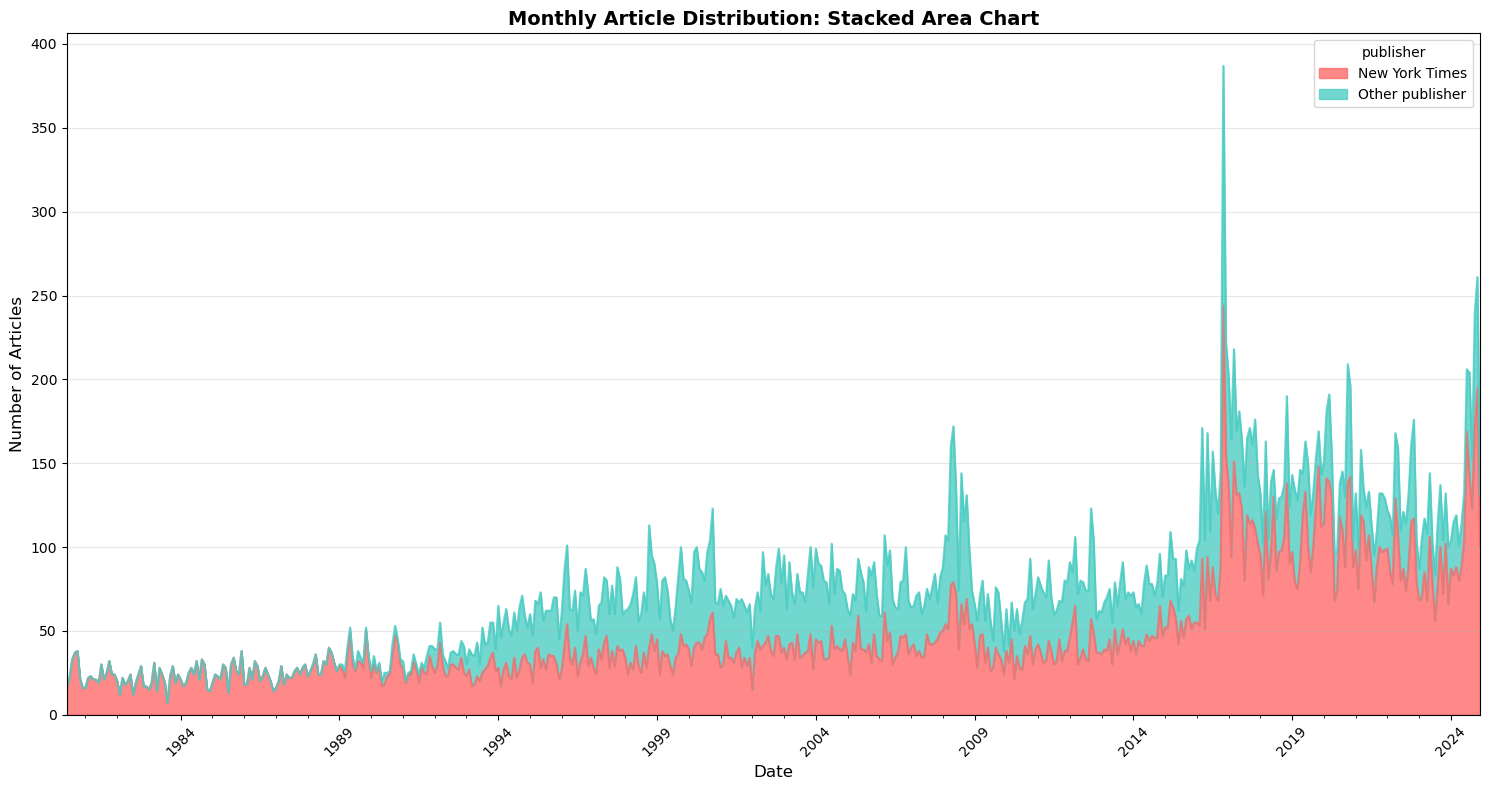

In [11]:
# Get publisher counts for the function
publisher_counts = df['publisher'].value_counts()

# Generate publisher comparison visualizations
plot_publisher_time_distribution(df, publisher_counts)

<a id="time_by_section"></a>
### Time Distribution by Section

Interactive comparison of section category distributions between NYT and other publishers.

In [12]:
# Create interactive pie chart comparison
interactive_pie_charts(df, "Interactive Section Category Distribution: NYT vs Others")

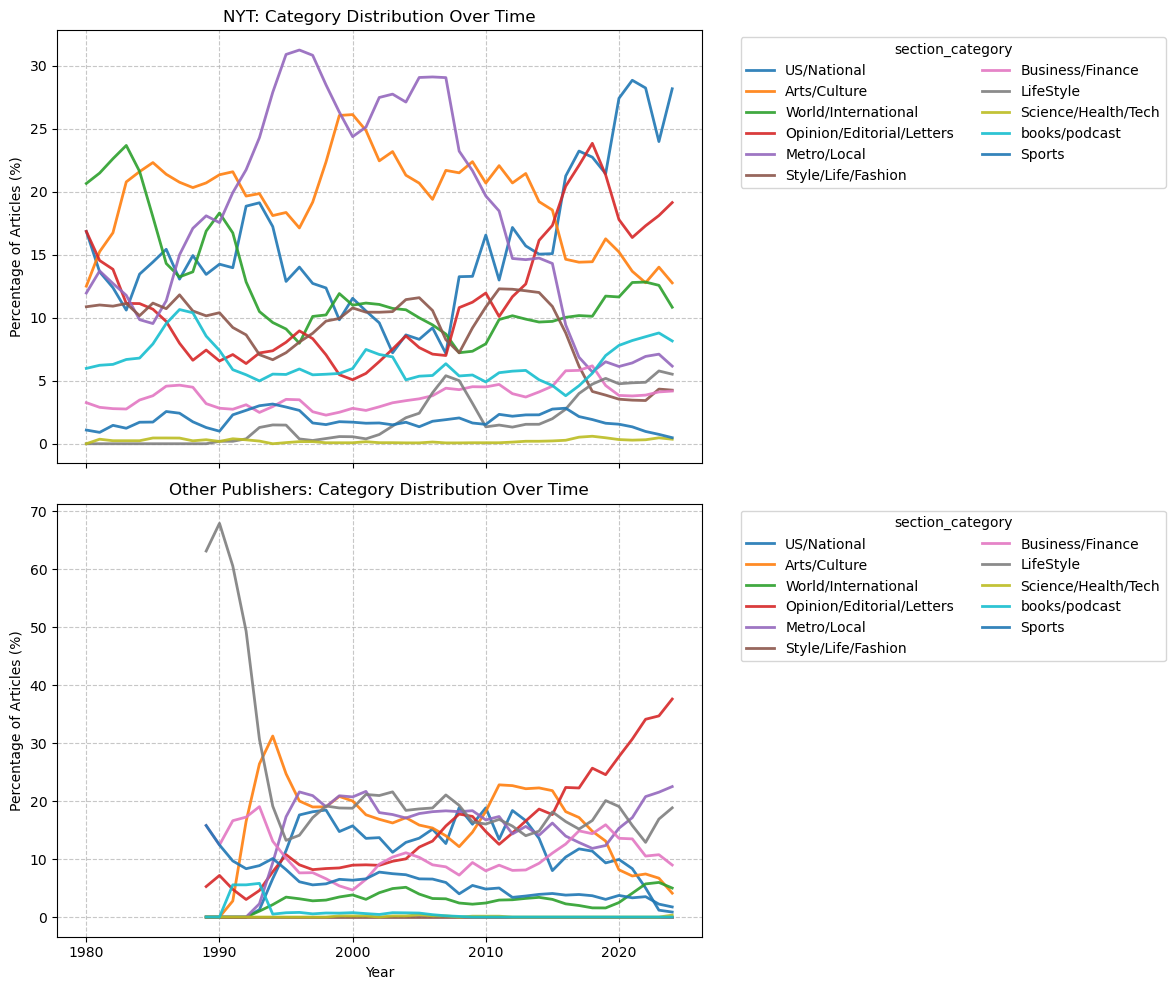

In [13]:
df['year'] = pd.to_datetime(df['date']).dt.year
nyt_mask = df['publisher'] == 'New York Times'
line_time_plot(
    df_articles_with_results=df,
    nyt_mask=nyt_mask,
    variable='section_category',
    title='Category Distribution Over Time',
    filename='category_distribution_over_time.png',
    variable_label='section_category',
    smooth_window=3
)

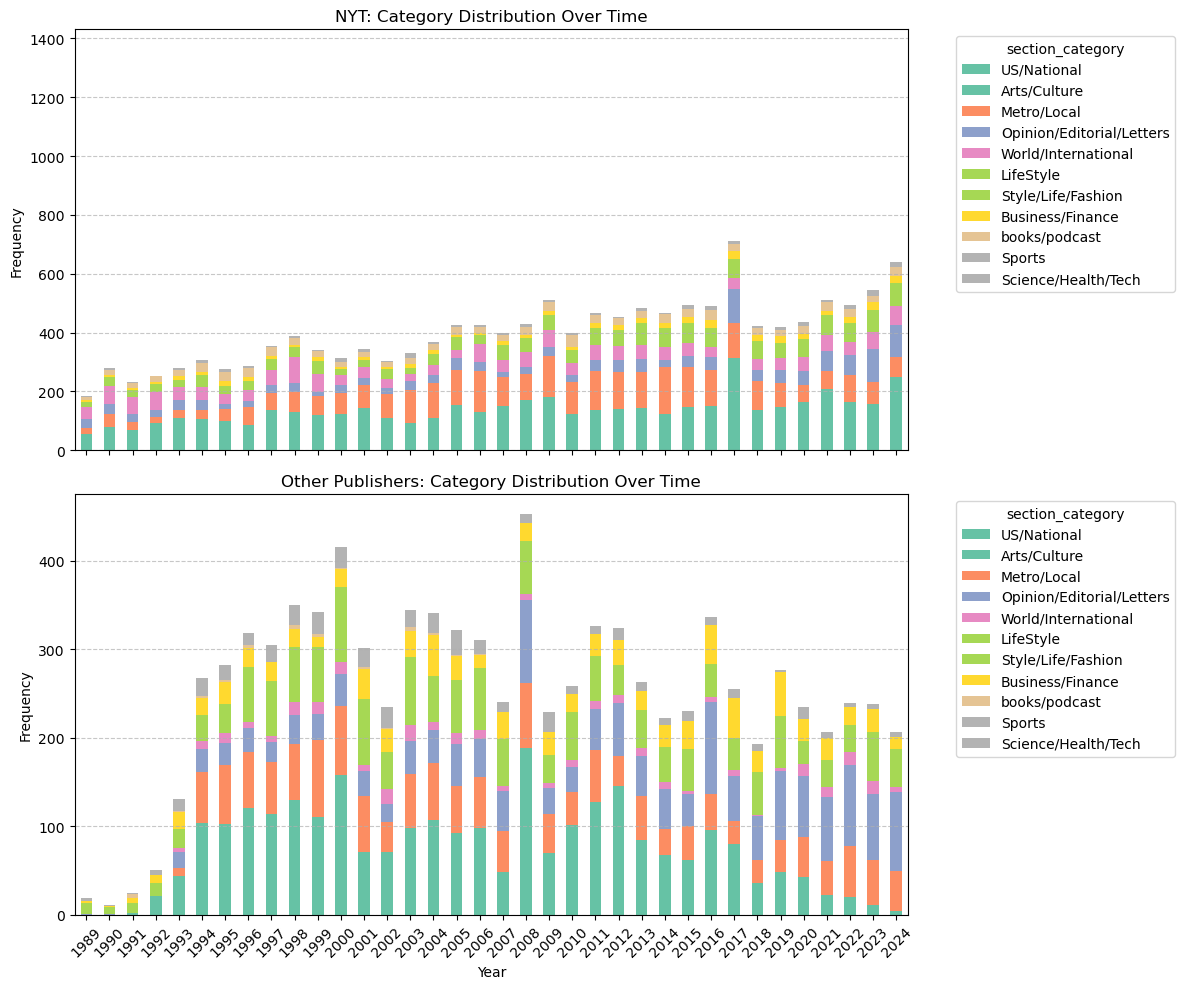

In [14]:
stacked_time_plot(
    df_articles_with_results=df,
    nyt_mask=nyt_mask,
    variable='section_category',
    title='Category Distribution Over Time'
)

Show percentage-based section distribution over time to highlight shifting coverage priorities.

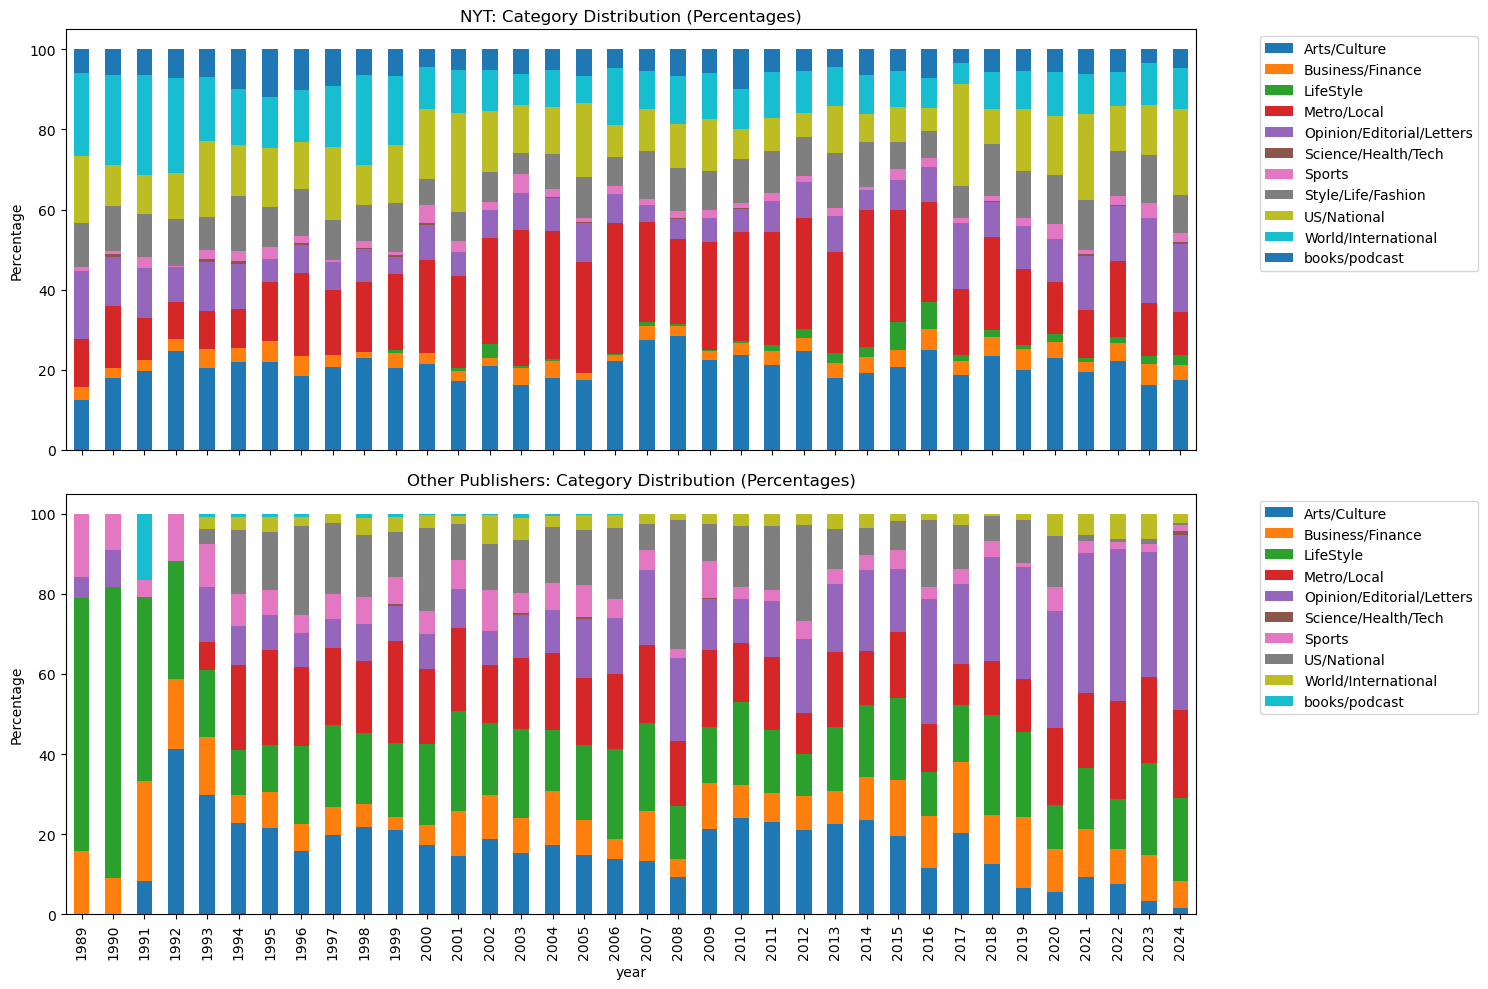

In [15]:
# Create proportional stacked plots
df['year'] = pd.to_datetime(df['date']).dt.year
nyt_mask = df['publisher'] == 'New York Times'
proportional_stacked_plot(df, nyt_mask, 'section_category', 
                         'Category Distribution (Percentages)')

In [16]:
unique_categories = df['section_category'].unique()
print("Unique categories using .unique():")
print(unique_categories)

Unique categories using .unique():
['US/National' None 'Arts/Culture' 'World/International'
 'Opinion/Editorial/Letters' 'Metro/Local' 'Style/Life/Fashion'
 'Business/Finance' 'LifeStyle' 'Science/Health/Tech' 'books/podcast'
 'Sports']


In [17]:
random_row = df[df['section_category'] == 'Arts/Culture'].sample(1)
article_index = random_row.index[0]

print(f"Article index: {article_index}")
print(f"Article body: {random_row['body'].iloc[0]}")

Article index: 28411
Article body: A New New Wave Of French Films
     The annual Rendez-Vous With French Cinema series is always one of the most popular at the Walter Reade Theater at Lincoln Center. But this year's series, which begins today with Jacques Audiard's "Read My Lips," Pascale Bailly's "God Is Great, I'm Not" and Mathieu Amalric's "Wimbledon Stadium," promises to be even more mobbed than ever (related article, Page 20). 
 It has been an amazing 12 months for the French cinema, which has had international triumphs at the art houses ("Amelie") and in the shopping malls ("Brotherhood of the Wolf"); here are 15 more films from one of the few national cinemas that have successfully managed to hold out against Hollywood.
"Yes, the French cinema is in good shape," said the filmmaker Claude Miller ("The Little Thief"), whose new thriller, "Betty Fisher and Other Stories," will be screened on March 15 and 16. (The series runs through March 17.) "But that's because there has always 

<a id="length_over_time"></a>
### Average Article Length Over Time

Analyze how article length has evolved over time, including:
- Overall trends with mean, median, and standard deviation
- Distribution by decade using boxplots
- Comparison between publishers


------------------------------------------------------------
ARTICLE LENGTH ANALYSIS OVER TIME
------------------------------------------------------------
Articles with valid word counts: 39,862 (100.0%)
Overall average article length: 1272 words
Median article length: 1055 words
Length range: 91 - 31,014 words


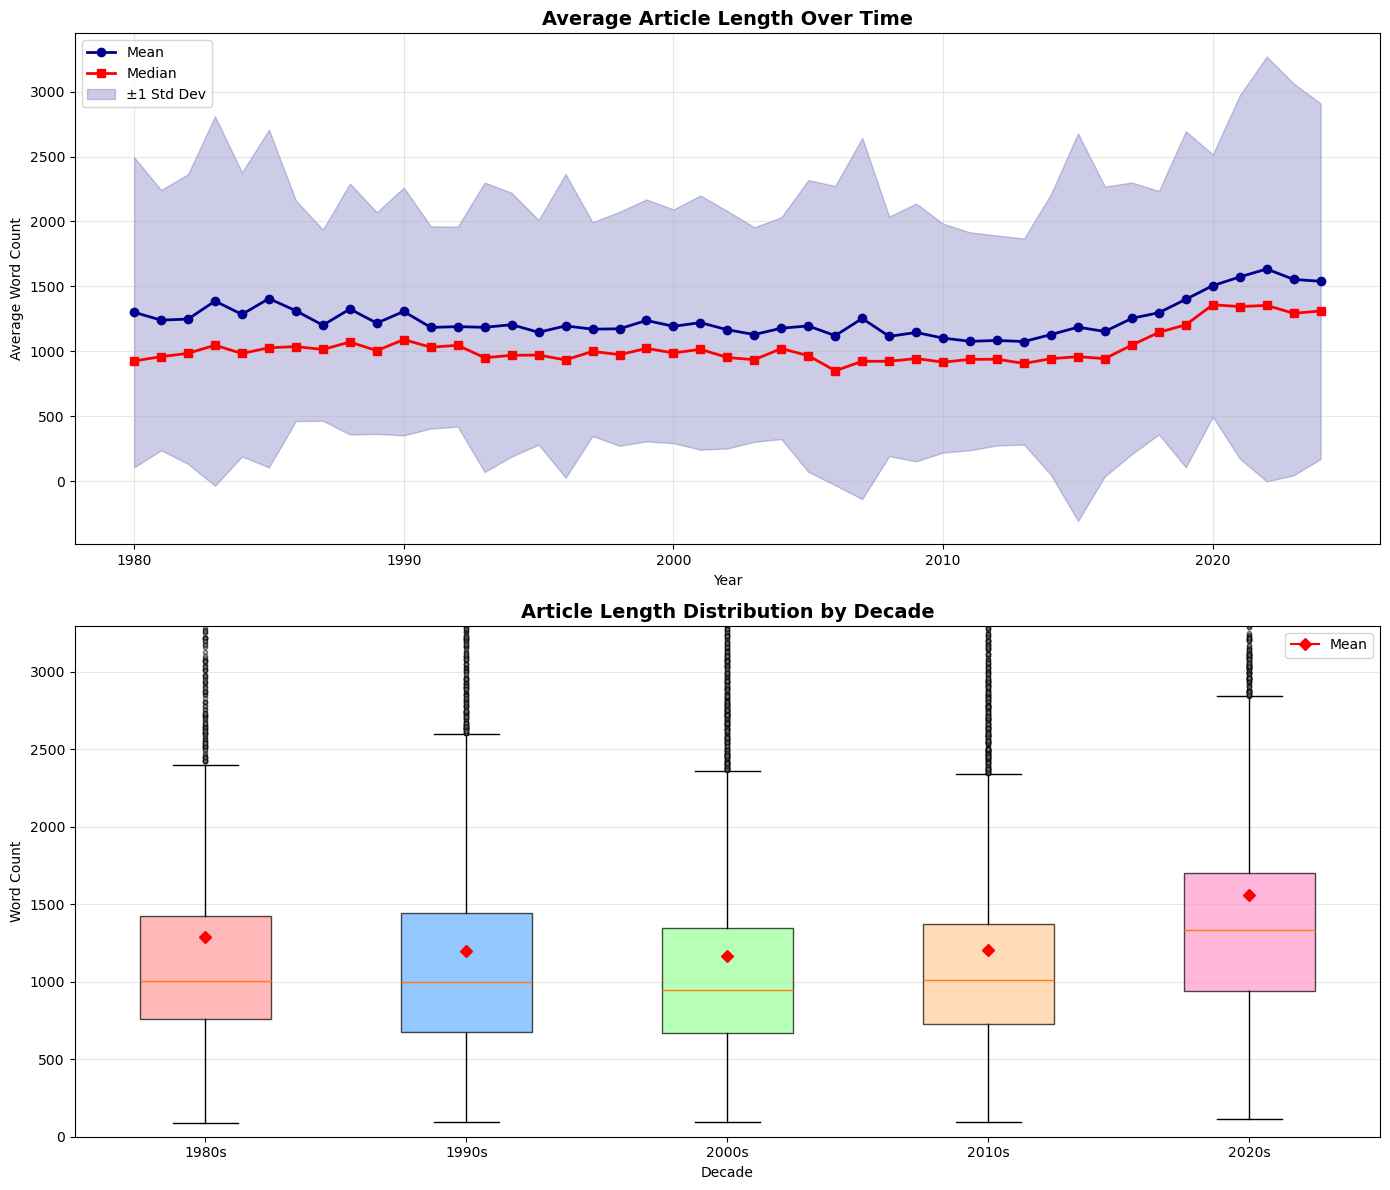


Decade-by-decade breakdown:
  1980s: 2,887 articles, median = 1008 words, mean = 1290 words
  1990s: 6,601 articles, median = 996 words, mean = 1196 words
  2000s: 9,538 articles, median = 950 words, mean = 1169 words
  2010s: 12,748 articles, median = 1012 words, mean = 1204 words
  2020s: 8,088 articles, median = 1335 words, mean = 1559 words


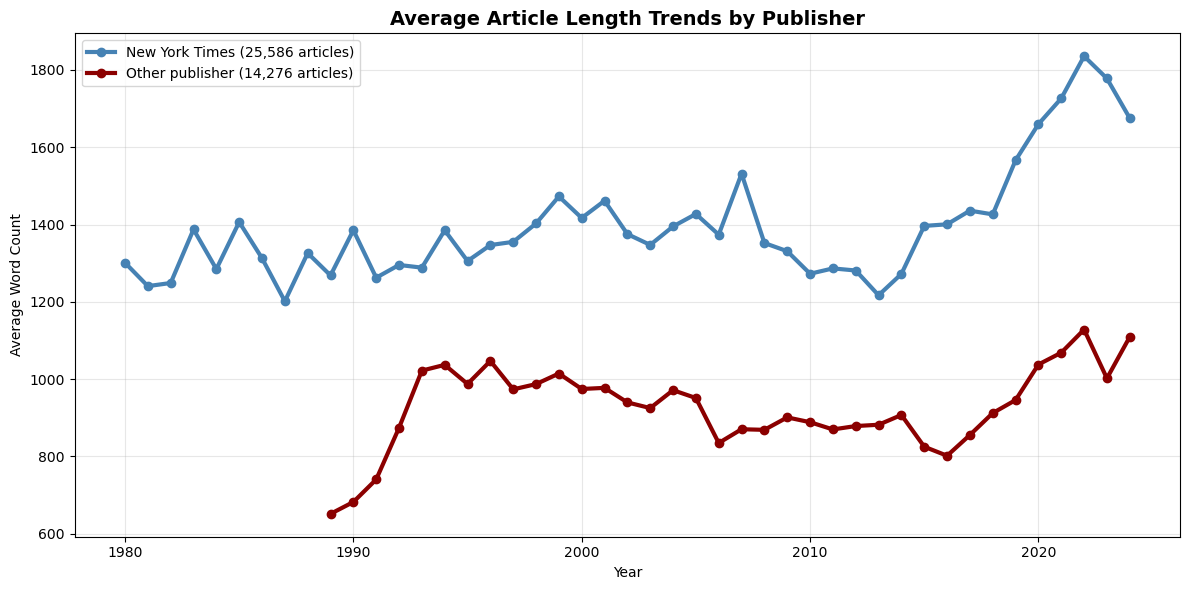


Length comparison by publisher:
  New York Times: 1458 words average, 1211 words median (25,586 articles)
  Other publisher: 940 words average, 807 words median (14,276 articles)


In [18]:
# Perform comprehensive article length analysis
analyze_article_length_over_time(df)